In [1]:
# import rapids_singlecell as sc
import scanpy as sc
import anndata as ad
import pandas as pd
import scvi
import numpy as np
import os

In [2]:
DATA_DIR = "/mnt/home/gokulg/data/"
OUT_DIR = "models/integrated_scvi/"
ANNOTATION_FILE = os.path.join(DATA_DIR, "embryos/annotation_v5.csv")
TYPES_TO_REMOVE = ["doublet"]

In [3]:
adata_qiu22 = sc.read_h5ad("/mnt/home/gokulg/data/qiu2022/qiu2022_combined.h5ad") # embryo is indexed by day
print('loaded qiu2022')
adata_qiu24 = sc.read_h5ad("/mnt/home/gokulg/data/qiu2024/qiu2024_1.h5ad")
print('loaded qiu2024_1')
adata_devmap = sc.read_h5ad("/mnt/home/gokulg/data/embryos/combined_counts.h5ad")
print('loaded devmap')

# sc.get.anndata_to_GPU(adata_qiu22)
# sc.get.anndata_to_GPU(adata_qiu24)
# sc.get.anndata_to_GPU(adata_devmap)

loaded qiu2022
loaded qiu2024_1
loaded devmap


In [5]:
print([x for x in adata_qiu22.obs['day'].unique() if '8' in x])

['E8', 'E8.25', 'E8.5a', 'E8.5b']


In [ ]:
qiu24_overlapping_days = ['E8.5', 'E8.75', 'E9.0', 'E9.5', 'E9.25', 'E9.75', 'E10.0']
qiu22_overlapping_days = ['E6.5', 'E6.75', 'E7.0', 'E7.25', 'E7.5', 'E7.75', 'E8.0', 'E8.25', 'E8.5a', 'E8.5b']

In [5]:
hvgs = pd.read_csv(f"{DATA_DIR}embryos/hvg_v5.csv", header=None)[0].tolist()
conversion = pd.read_csv(f"{DATA_DIR}mm39_annotations.csv", header=0)
gene_symbols = pd.read_csv(f"{DATA_DIR}gene_symbols.tsv", sep='\t', header=0)

In [6]:
conversion_dict = {}

for i, row in gene_symbols.iterrows():
    conversion_dict[row['Gene stable ID']] = row['MGI symbol']
    # conversion_dict[row['MGI symbol']] = row['Gene stable ID']
    conversion_dict[row['Gene stable ID'].split('.')[0]] = row['MGI symbol']

# convert var_names for both qiu adatas
for adata in [adata_qiu22, adata_qiu24]:
    # adata.var_names = adata.var['features'].tolist()
    adata.var_names = [str(conversion_dict.get(v, v)) for v in adata.var_names]
    adata.var_names_make_unique()

In [7]:
# find common HVGs across all 3 datasets
common_hvgs = [h for h in hvgs if h in adata_qiu22.var_names and h in adata_qiu24.var_names and h in adata_devmap.var_names]
print(f"Common HVGs across all 3 datasets: {len(common_hvgs)} / {len(hvgs)}")

# subset each dataset to common HVGs
adata_qiu22_hvg = adata_qiu22[:, common_hvgs].copy()
adata_qiu24_hvg = adata_qiu24[:, common_hvgs].copy()
adata_devmap_hvg = adata_devmap[:, common_hvgs].copy()

# add annotations and remove unwanted types from devmap
adata_devmap_hvg.obs['time'] = [float(x.split('-')[0][1:]) for x in adata_devmap_hvg.obs['embryo'].values]
annotations = pd.read_csv(ANNOTATION_FILE, index_col=0)
adata_devmap_hvg.obs = adata_devmap_hvg.obs.join(annotations, how="left")
adata_devmap_hvg = adata_devmap_hvg[~adata_devmap_hvg.obs["annotation"].isin(TYPES_TO_REMOVE)].copy()
# adata_devmap_hvg = adata_devmap_hvg[adata_devmap_hvg.obs['time'] < 8.6, :].copy()

# filter to overlapping days
adata_qiu22_hvg = adata_qiu22_hvg[adata_qiu22_hvg.obs['day'].isin(qiu22_overlapping_days)].copy()
adata_qiu24_hvg = adata_qiu24_hvg[adata_qiu24_hvg.obs['day'].isin(qiu24_overlapping_days)].copy()

# check that data are integer counts
assert (adata_qiu22_hvg.X.data[:10].astype(int) == adata_qiu22_hvg.X.data[:10]).all()
assert (adata_qiu24_hvg.X.data[:10].astype(int) == adata_qiu24_hvg.X.data[:10]).all()
assert (adata_devmap_hvg.X.data[:10].astype(int) == adata_devmap_hvg.X.data[:10]).all()

print(f"Qiu2022 shape after filtering: {adata_qiu22_hvg.shape}")
print(f"Qiu2024 shape after filtering: {adata_qiu24_hvg.shape}")
print(f"devmap shape after filtering: {adata_devmap_hvg.shape}")
# concatenate all 3 datasets
combined = ad.concat(
    [adata_qiu22_hvg, adata_qiu24_hvg, adata_devmap_hvg],
    axis='obs', join='outer', label='dataset',
    keys=['qiu2022', 'qiu2024', 'devmap']
)
print(f"Combined shape: {combined.shape}")

Common HVGs across all 3 datasets: 4456 / 5000
Qiu2022 shape after filtering: (232700, 4456)
Qiu2024 shape after filtering: (2054584, 4456)
devmap shape after filtering: (1795384, 4456)
Combined shape: (4082668, 4456)


In [8]:
# sc.get.anndata_to_GPU(combined)

# save counts in layers counts
combined.layers["counts"] = combined.X.copy()
sc.pp.normalize_total(combined, target_sum=1e4)
sc.pp.log1p(combined)

In [9]:
# compute DEGs separately for each time range, then remove from combined

k = 250
all_deg_names = set()

# --- DEGs between devmap (time <= 8.5) and qiu2022 ---
mask_early = combined.obs['dataset'].isin(['devmap', 'qiu2022']).values
mask_devmap_early = (combined.obs['dataset'] == 'devmap') & (combined.obs['time'] <= 8.51)
mask_early = mask_early & (mask_devmap_early | (combined.obs['dataset'] == 'qiu2022')).values

early = combined[mask_early].copy()
n_sub_early = min(100_000, early.shape[0])
n_per_ds_early = n_sub_early // early.obs['dataset'].nunique()
idx_early = np.concatenate([
    np.random.choice(np.where(early.obs['dataset'] == d)[0],
                     size=min(n_per_ds_early, (early.obs['dataset'] == d).sum()), replace=False)
    for d in early.obs['dataset'].unique()
])
early_sub = early[idx_early].copy()
sc.tl.rank_genes_groups(early_sub, 'dataset', method='wilcoxon')
early_df = sc.get.rank_genes_groups_df(early_sub, group=None, key='rank_genes_groups')
all_deg_names.update(early_df.groupby('group').head(k)['names'].values)

# --- DEGs between devmap (time >= 8.5) and qiu2024 ---
mask_late = combined.obs['dataset'].isin(['devmap', 'qiu2024']).values
mask_devmap_late = (combined.obs['dataset'] == 'devmap') & (combined.obs['time'] >= 8.49)
mask_late = mask_late & (mask_devmap_late | (combined.obs['dataset'] == 'qiu2024')).values

late = combined[mask_late].copy()
n_sub_late = min(100_000, late.shape[0])
n_per_ds_late = n_sub_late // late.obs['dataset'].nunique()
idx_late = np.concatenate([
    np.random.choice(np.where(late.obs['dataset'] == d)[0],
                     size=min(n_per_ds_late, (late.obs['dataset'] == d).sum()), replace=False)
    for d in late.obs['dataset'].unique()
])
late_sub = late[idx_late].copy()
sc.tl.rank_genes_groups(late_sub, 'dataset', method='wilcoxon')
late_df = sc.get.rank_genes_groups_df(late_sub, group=None, key='rank_genes_groups')
all_deg_names.update(late_df.groupby('group').head(k)['names'].values)

# --- Remove union of DEGs from combined ---
gene_subset = [x for x in combined.var_names if x not in all_deg_names]
print(f"Removing {len(all_deg_names)} DEGs, keeping {len(gene_subset)} genes")
combined = combined[:, gene_subset].copy()

combined

/tmp/ipykernel_79891/20456313.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_deg_names.update(early_df.groupby('group').head(k)['names'].values)
/tmp/ipykernel_79891/20456313.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_deg_names.update(late_df.groupby('group').head(k)['names'].values)


Removing 674 DEGs, keeping 3782 genes


AnnData object with n_obs × n_vars = 4082668 × 3782
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'day', 'group', 'cell_state', 'cell_type', 'somite_stage', 'cell_id', 'keep', 'embryo_id', 'experimental_batch', 'capture', 'cellBC', 'embryo', 'type', 'n_genes_by_counts', 'total_counts', 'detection_rate', 'clade', 'clone', 'time', 'annotation', 'dataset'
    uns: 'log1p'
    layers: 'counts'

In [10]:
setup_kwargs = {}
setup_kwargs['categorical_covariate_keys'] = ['dataset']
scvi.model.SCVI.setup_anndata(combined, layer='counts', **setup_kwargs)

In [11]:
model = scvi.model.SCVI(
    combined, 
    n_layers=2, 
    n_latent=50,
    n_hidden=512,
    gene_likelihood='nb',
    dispersion='gene-batch'
)

In [12]:
model.train(
    max_epochs=20, early_stopping=False,
    # plan_kwargs={'kl_weight' : 1},
)

/mnt/home/gokulg/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/home/gokulg/miniconda3/envs/rapids_singlecell/l ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/mnt/home/gokulg/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/home/g

Training:   0%|          | 0/20 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [13]:
model.save(os.path.join(OUT_DIR, "scvi_model"), overwrite=True)
combined.obsm["X_scvi"] = model.get_latent_representation()
print(f"embeddings computed, shape: {combined.obsm['X_scvi'].shape}")

# subsample for umap
n_sub = min(500_000, combined.shape[0])
idx = np.random.choice(combined.shape[0], size=n_sub, replace=False)
combined_sub = combined[idx].copy()

# compute and save umaps
sc.pp.neighbors(combined_sub, use_rep="X_scvi")
sc.tl.umap(combined_sub)

embeddings computed, shape: (4082668, 50)


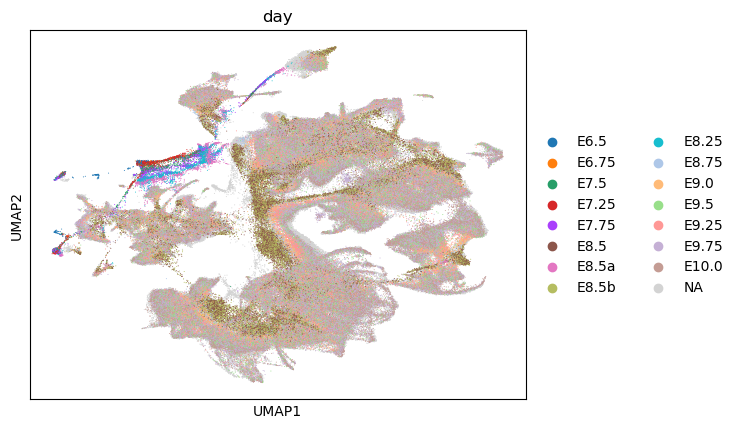

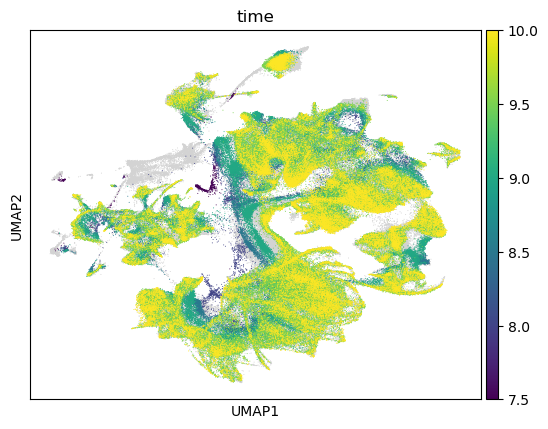

In [14]:
sc.pl.umap(combined_sub, color=["day"], size=2, hspace=0.6)
sc.pl.umap(combined_sub, color=["time"], size=2, hspace=0.6)

In [15]:
combined.write_h5ad(os.path.join(DATA_DIR, "qiu22-24_integrated_scvi.h5ad"))